# C5 ML Localization Pipeline -- Reference-in-Search Spot Localization

**Goal**: Train a robust, high-accuracy ML model to localize a reference pattern
within a search image. Evaluate Precision / Recall / F1 / Accuracy broken down
by noise level (CLEAN / LOW / MEDIUM / HIGH / EXTREME) and difficulty (L0-L3).

**Dataset**: 14,000 frozen samples (10K train / 2K val / 2K test).
Each sample has 100 pre-extracted candidate positions with SSD scores.
The ML task: rank candidates so that the top-1 pick lands within 5 px
(Chebyshev) of the ground-truth position.

**Pipeline**:
1. Load data & engineer 20+ features from stored candidates
2. Baseline: C4 classical (argmin SSD)
3. Train: RandomForest, HistGradientBoosting, XGBoost
4. Hyperparameter-tune the best with Optuna (100 trials)
5. Ensemble top models
6. Full metrics report per noise level & difficulty

In [1]:
# %% -- Imports & Configuration
from __future__ import annotations

import json
import math
import os
import random
import sys
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Optional imports -- degrade gracefully
try:
    import xgboost as xgb
    HAS_XGB = True
    print(f"[OK] XGBoost {xgb.__version__}")
except ImportError:
    HAS_XGB = False
    print("[--] XGBoost not installed -- skipping XGB model")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
    print(f"[OK] Optuna {optuna.__version__}")
except ImportError:
    HAS_OPTUNA = False
    print("[--] Optuna not installed -- using manual parameter setup")

# ── Exact Dataset Location ──────────────────────────────────────────────────
DATA_ROOT  = Path(r"D:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\data\phase_c\c5_ml_dataset")
IMAGES_DIR = DATA_ROOT / "images"
INDEX_PATH = DATA_ROOT / "index.json"

# ── Local Output Directories (in the new folder where this file runs) ───────
CURRENT_DIR = Path.cwd()
REPO_ROOT   = CURRENT_DIR  # set to a different path if you want a second copy saved elsewhere
MODEL_DIR   = CURRENT_DIR
REPORT_DIR  = CURRENT_DIR / "reports"
PLOTS_DIR   = CURRENT_DIR / "plots"

for p in [REPORT_DIR, PLOTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# -- Configuration ----------------------------------------------------------
SEED = 42
MATCH_TOLERANCE_PX = 5.0
IMAGE_SIZE = 1000

NOISE_LEVELS = ["CLEAN", "LOW", "MEDIUM", "HIGH", "EXTREME"]
DIFFICULTIES = ["L0", "L1", "L2", "L3"]
NOISE_ENC = {n: i for i, n in enumerate(NOISE_LEVELS)}
DIFF_ENC = {d: i for i, d in enumerate(DIFFICULTIES)}

random.seed(SEED)
np.random.seed(SEED)

print(f"\n{'='*70}")
print(f"  C5 ML LOCALIZATION PIPELINE")
print(f"  Dataset path : {DATA_ROOT}")
print(f"  Images path  : {IMAGES_DIR}")
print(f"  Index path   : {INDEX_PATH}")
print(f"  Notebook dir : {CURRENT_DIR}")
print(f"  Model saves  : Directly in {MODEL_DIR}")
print(f"  Reports dir  : {REPORT_DIR}")
print(f"  Plots dir    : {PLOTS_DIR}")
print(f"  Seed         : {SEED}")
print(f"{'='*70}\n")


[OK] XGBoost 3.4.1
[OK] Optuna 4.9.0

  C5 ML LOCALIZATION PIPELINE
  Dataset path : D:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\data\phase_c\c5_ml_dataset
  Images path  : D:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\data\phase_c\c5_ml_dataset\images
  Index path   : D:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\data\phase_c\c5_ml_dataset\index.json
  Notebook dir : d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense
  Model saves  : Directly in d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense
  Reports dir  : d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\reports
  Plots dir    : d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\plots
  Seed         : 42



## 1 . Data Loading

In [2]:
print("Loading index.json ...")
t0 = time.time()
with open(INDEX_PATH, "r", encoding="utf-8") as f:
    all_records = json.load(f)["samples"]

assert len(all_records) == 14_000, f"Expected 14000 samples, got {len(all_records)}"

train_metas = [r for r in all_records if r["split"] == "train"]
val_metas = [r for r in all_records if r["split"] == "validation"]
test_metas = [r for r in all_records if r["split"] == "test"]

print(f"  Train      : {len(train_metas):,}")
print(f"  Validation : {len(val_metas):,}")
print(f"  Test       : {len(test_metas):,}")
print(f"  Loaded in  : {time.time()-t0:.1f}s")

# Quick distribution check
for name, metas in [("TRAIN", train_metas), ("VAL", val_metas)]:
    noise_dist = Counter(m["noise_condition"] for m in metas)
    diff_dist = Counter(m["difficulty"] for m in metas)
    print(f"\n  {name} noise : {dict(sorted(noise_dist.items()))}")
    print(f"  {name} diff  : {dict(sorted(diff_dist.items()))}")

Loading index.json ...
  Train      : 10,000
  Validation : 2,000
  Test       : 2,000
  Loaded in  : 0.1s

  TRAIN noise : {'CLEAN': 2000, 'EXTREME': 2000, 'HIGH': 2000, 'LOW': 2000, 'MEDIUM': 2000}
  TRAIN diff  : {'L0': 2500, 'L1': 2500, 'L2': 2500, 'L3': 2500}

  VAL noise : {'CLEAN': 400, 'EXTREME': 400, 'HIGH': 400, 'LOW': 400, 'MEDIUM': 400}
  VAL diff  : {'L0': 500, 'L1': 500, 'L2': 500, 'L3': 500}


## 2 . Feature Engineering

We extract **20 features** per candidate from the stored `candidates.json`
files (no image loading needed). These include raw SSD, positional features,
and *per-sample relative* features that capture how a candidate compares to
its siblings within the same sample.

In [3]:
FEATURE_NAMES = [
    "ssd_raw",                # 0  raw SSD score
    "center_x",               # 1  candidate center x
    "center_y",               # 2  candidate center y
    "rank",                   # 3  SSD-ascending rank (0=best)
    "difficulty_enc",          # 4  L0=0..L3=3
    "noise_enc",               # 5  CLEAN=0..EXTREME=4
    "noise_multiplier",        # 6  from metadata
    "search_noise_std",        # 7  from metadata
    "ref_noise_std",           # 8  from metadata
    "line_scan_corr",          # 9  from metadata
    "ssd_ratio_to_best",       # 10 ssd / min(ssd) per sample  (>=1)
    "ssd_gap_to_best",         # 11 ssd - min(ssd)
    "ssd_zscore",              # 12 z-score within sample
    "log_ssd",                 # 13 log(1 + ssd)
    "rank_pct",                # 14 rank / n_candidates
    "dist_to_center",          # 15 euclidean dist from (500,500)
    "x_norm",                  # 16 center_x / 1000
    "y_norm",                  # 17 center_y / 1000
    "ssd_ratio_to_second",     # 18 ssd / ssd_of_rank1  (separability)
    "ssd_ratio_to_median",     # 19 ssd / median(ssd) per sample
]

N_FEATURES = len(FEATURE_NAMES)
print(f"Feature count: {N_FEATURES}")
print(f"Features: {FEATURE_NAMES}")


def build_feature_matrix(metas: list[dict], desc: str = "") -> tuple[np.ndarray, np.ndarray, list[dict]]:
    """Build (X, y, row_meta) from candidates.json for a list of samples."""
    X_list = []
    y_list = []
    meta_list = []
    t0 = time.time()

    for idx, meta in enumerate(metas):
        cand_path = Path(meta["reference_png"]).parent / "candidates.json"
        if not cand_path.exists():
            cand_path = IMAGES_DIR / meta["sample_id"] / meta["noise_condition"] / "candidates.json"
        if not cand_path.exists():
            cand_path = DATA_ROOT / meta["reference_png"].replace("\\", "/")
            cand_path = cand_path.parent / "candidates.json"

        with open(cand_path, "r", encoding="utf-8") as f:
            cdata = json.load(f)

        candidates = cdata["candidates"]
        gt_x, gt_y = float(meta["gt_x"]), float(meta["gt_y"])
        n_cand = len(candidates)

        # Sort by SSD ascending to define rank
        cands_sorted = sorted(candidates, key=lambda c: c["ssd_raw"])
        ssd_values = np.array([c["ssd_raw"] for c in cands_sorted], dtype=np.float64)
        ssd_min = ssd_values[0] if len(ssd_values) > 0 else 1.0
        ssd_max = ssd_values[-1] if len(ssd_values) > 0 else 1.0
        ssd_mean = ssd_values.mean() if len(ssd_values) > 0 else 1.0
        ssd_std = ssd_values.std() if len(ssd_values) > 0 else 1.0
        ssd_median = np.median(ssd_values) if len(ssd_values) > 0 else 1.0
        ssd_second = ssd_values[1] if len(ssd_values) > 1 else ssd_min

        noise_mult = float(meta.get("noise_multiplier", 0.0))
        search_noise = float(meta.get("search_noise_std_px", 0.0))
        ref_noise = float(meta.get("reference_noise_std_px", 0.0))
        line_scan = float(meta.get("line_scan_correlation_strength", 0.0))
        diff_e = DIFF_ENC[meta["difficulty"]]
        noise_e = NOISE_ENC[meta["noise_condition"]]

        for rank, cand in enumerate(cands_sorted):
            cx = float(cand["center_x"])
            cy = float(cand["center_y"])
            ssd = float(cand["ssd_raw"])

            # Label: Chebyshev <= 5px
            cheb = max(abs(cx - gt_x), abs(cy - gt_y))
            label = 1 if cheb <= MATCH_TOLERANCE_PX else 0

            # Build feature vector
            ssd_safe = max(ssd_min, 1e-10)
            ssd_std_safe = max(ssd_std, 1e-10)
            ssd_second_safe = max(ssd_second, 1e-10)
            ssd_median_safe = max(ssd_median, 1e-10)

            feat = np.array([
                ssd,                                          # 0  ssd_raw
                cx,                                           # 1  center_x
                cy,                                           # 2  center_y
                float(rank),                                  # 3  rank
                float(diff_e),                                # 4  difficulty_enc
                float(noise_e),                               # 5  noise_enc
                noise_mult,                                   # 6  noise_multiplier
                search_noise,                                 # 7  search_noise_std
                ref_noise,                                    # 8  ref_noise_std
                line_scan,                                    # 9  line_scan_corr
                ssd / ssd_safe,                               # 10 ssd_ratio_to_best
                ssd - ssd_min,                                # 11 ssd_gap_to_best
                (ssd - ssd_mean) / ssd_std_safe,              # 12 ssd_zscore
                np.log1p(ssd),                                # 13 log_ssd
                rank / max(n_cand, 1),                        # 14 rank_pct
                np.sqrt((cx - 500)**2 + (cy - 500)**2),      # 15 dist_to_center
                cx / 1000.0,                                  # 16 x_norm
                cy / 1000.0,                                  # 17 y_norm
                ssd / ssd_second_safe,                        # 18 ssd_ratio_to_second
                ssd / ssd_median_safe,                        # 19 ssd_ratio_to_median
            ], dtype=np.float64)

            X_list.append(feat)
            y_list.append(label)
            meta_list.append({
                "sample_id": meta["sample_id"],
                "difficulty": meta["difficulty"],
                "noise_condition": meta["noise_condition"],
                "gt_x": gt_x,
                "gt_y": gt_y,
                "cx": cx,
                "cy": cy,
                "rank": rank,
            })

        if (idx + 1) % 500 == 0:
            elapsed = time.time() - t0
            print(f"  [{desc}] {idx+1}/{len(metas)} samples "
                  f"({len(X_list):,} candidates) -- {elapsed:.1f}s")

    X = np.array(X_list, dtype=np.float64)
    y = np.array(y_list, dtype=np.int64)
    elapsed = time.time() - t0
    n_pos = int(y.sum())
    n_neg = len(y) - n_pos
    print(f"  [{desc}] Done: {X.shape[0]:,} candidates, "
          f"{n_pos:,} pos ({100*n_pos/len(y):.2f}%), "
          f"{n_neg:,} neg - {elapsed:.1f}s")
    return X, y, meta_list


Feature count: 20
Features: ['ssd_raw', 'center_x', 'center_y', 'rank', 'difficulty_enc', 'noise_enc', 'noise_multiplier', 'search_noise_std', 'ref_noise_std', 'line_scan_corr', 'ssd_ratio_to_best', 'ssd_gap_to_best', 'ssd_zscore', 'log_ssd', 'rank_pct', 'dist_to_center', 'x_norm', 'y_norm', 'ssd_ratio_to_second', 'ssd_ratio_to_median']


In [4]:
# %% -- Build TRAIN / VALIDATION feature matrices
# (This was missing: nothing downstream defines X_train/y_train/meta_train
#  or X_val/y_val/meta_val without this cell, causing a NameError as soon as
#  the baseline / training cells run.)
X_train, y_train, meta_train = build_feature_matrix(train_metas, "TRAIN")
X_val, y_val, meta_val = build_feature_matrix(val_metas, "VAL")

print(f"\n  X_train: {X_train.shape}, X_val: {X_val.shape}")


  [TRAIN] 500/10000 samples (50,003 candidates) -- 15.0s
  [TRAIN] 1000/10000 samples (100,006 candidates) -- 32.7s
  [TRAIN] 1500/10000 samples (150,009 candidates) -- 51.7s
  [TRAIN] 2000/10000 samples (200,010 candidates) -- 67.0s
  [TRAIN] 2500/10000 samples (250,018 candidates) -- 74.4s
  [TRAIN] 3000/10000 samples (300,021 candidates) -- 82.5s
  [TRAIN] 3500/10000 samples (350,025 candidates) -- 92.8s
  [TRAIN] 4000/10000 samples (400,028 candidates) -- 100.1s
  [TRAIN] 4500/10000 samples (450,035 candidates) -- 105.8s
  [TRAIN] 5000/10000 samples (500,038 candidates) -- 111.4s
  [TRAIN] 5500/10000 samples (550,043 candidates) -- 117.4s
  [TRAIN] 6000/10000 samples (600,049 candidates) -- 123.2s
  [TRAIN] 6500/10000 samples (650,057 candidates) -- 128.6s
  [TRAIN] 7000/10000 samples (700,062 candidates) -- 134.5s
  [TRAIN] 7500/10000 samples (750,066 candidates) -- 140.6s
  [TRAIN] 8000/10000 samples (800,071 candidates) -- 146.5s
  [TRAIN] 8500/10000 samples (850,073 candidates)

## 3 . Evaluation Infrastructure

Two levels of evaluation:
- **Candidate-level**: Binary classification metrics (P / R / F1)
- **Sample-level localization**: Top-1 candidate within 5 px of GT

In [5]:
def candidate_metrics(y_true, y_scores, threshold=0.5):
    """Binary classification metrics at a given threshold."""
    y_pred = (np.asarray(y_scores) >= threshold).astype(int)
    y_t = np.asarray(y_true)
    tp = int(((y_pred == 1) & (y_t == 1)).sum())
    fp = int(((y_pred == 1) & (y_t == 0)).sum())
    fn = int(((y_pred == 0) & (y_t == 1)).sum())
    tn = int(((y_pred == 0) & (y_t == 0)).sum())
    n = len(y_t)
    acc = (tp + tn) / n if n else 0
    prec = tp / (tp + fp) if (tp + fp) else 0
    rec = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
    try:
        auc = roc_auc_score(y_t, y_scores)
    except ValueError:
        auc = 0
    return {
        "accuracy": round(acc, 4),
        "precision": round(prec, 4),
        "recall": round(rec, 4),
        "f1": round(f1, 4),
        "auc": round(auc, 4),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "n": n,
    }


def localization_eval(y_scores, meta_rows, desc=""):
    """Sample-level localization: for each sample, pick the highest-scored
    candidate and check if it's within 5px Chebyshev of GT.

    Returns overall + per-noise + per-difficulty breakdown.
    """
    # Group candidates by (sample_id, noise_condition)
    by_sample = defaultdict(list)
    for i, m in enumerate(meta_rows):
        key = (m["sample_id"], m["noise_condition"])
        by_sample[key].append(i)

    results = []
    for (sid, noise), idxs in by_sample.items():
        scores = y_scores[idxs]
        best_idx = idxs[int(np.argmax(scores))]
        m = meta_rows[best_idx]
        px, py = m["cx"], m["cy"]
        gx, gy = m["gt_x"], m["gt_y"]
        cheb = max(abs(px - gx), abs(py - gy))
        euclid = np.sqrt((px - gx)**2 + (py - gy)**2)
        success = cheb <= MATCH_TOLERANCE_PX

        results.append({
            "sample_id": sid,
            "noise_condition": noise,
            "difficulty": meta_rows[idxs[0]]["difficulty"],
            "success": success,
            "cheb_error": cheb,
            "euclid_error": euclid,
            "pred_x": px,
            "pred_y": py,
        })

    df = pd.DataFrame(results)

    def summarize(sub):
        if len(sub) == 0:
            return {"n": 0, "success_rate": 0, "mean_err": 0, "median_err": 0}
        return {
            "n": len(sub),
            "success_rate": round(sub["success"].mean(), 4),
            "mean_err": round(sub["euclid_error"].mean(), 2),
            "median_err": round(sub["euclid_error"].median(), 2),
        }

    overall = summarize(df)
    by_noise = {n: summarize(df[df["noise_condition"] == n]) for n in NOISE_LEVELS}
    by_diff = {d: summarize(df[df["difficulty"] == d]) for d in DIFFICULTIES}

    if desc:
        print(f"\n  [{desc}] Localization Success: {overall['success_rate']*100:.2f}%  "
              f"(mean err {overall['mean_err']:.1f}px, median {overall['median_err']:.1f}px)")

    return {"overall": overall, "by_noise": by_noise, "by_difficulty": by_diff, "details": df}


def full_report(model_name, y_scores_val, y_val, meta_val, threshold=0.5):
    """Print comprehensive candidate-level + localization metrics."""
    print(f"\n{'='*70}")
    print(f"  MODEL: {model_name}")
    print(f"{'='*70}")

    # Candidate-level overall
    cm = candidate_metrics(y_val, y_scores_val, threshold)
    print(f"\n  -- Candidate-Level Classification (threshold={threshold}) --")
    print(f"  Accuracy  : {cm['accuracy']:.4f}")
    print(f"  Precision : {cm['precision']:.4f}")
    print(f"  Recall    : {cm['recall']:.4f}")
    print(f"  F1        : {cm['f1']:.4f}")
    print(f"  AUC-ROC   : {cm['auc']:.4f}")

    # Candidate-level per noise
    print(f"\n  -- Candidate-Level per Noise --")
    noise_labels = [m["noise_condition"] for m in meta_val]
    header = f"  {'Noise':<10} {'Acc':>8} {'Prec':>8} {'Recall':>8} {'F1':>8} {'N':>8}"
    print(header)
    print(f"  {'-'*50}")
    noise_metrics = {}
    for noise in NOISE_LEVELS:
        mask = np.array([n == noise for n in noise_labels])
        if mask.sum() == 0:
            continue
        nm = candidate_metrics(y_val[mask], y_scores_val[mask], threshold)
        noise_metrics[noise] = nm
        print(f"  {noise:<10} {nm['accuracy']:>8.4f} {nm['precision']:>8.4f} "
              f"{nm['recall']:>8.4f} {nm['f1']:>8.4f} {nm['n']:>8,}")

    # Candidate-level per difficulty
    print(f"\n  -- Candidate-Level Binary Classification (NOT Localization) " f"(threshold={threshold}) --")
    diff_labels = [m["difficulty"] for m in meta_val]
    header = f"  {'Diff':<10} {'Acc':>8} {'Prec':>8} {'Recall':>8} {'F1':>8} {'N':>8}"
    print(header)
    print(f"  {'-'*50}")
    diff_metrics = {}
    for diff in DIFFICULTIES:
        mask = np.array([d == diff for d in diff_labels])
        if mask.sum() == 0:
            continue
        dm = candidate_metrics(y_val[mask], y_scores_val[mask], threshold)
        diff_metrics[diff] = dm
        print(f"  {diff:<10} {dm['accuracy']:>8.4f} {dm['precision']:>8.4f} "
              f"{dm['recall']:>8.4f} {dm['f1']:>8.4f} {dm['n']:>8,}")

    # Sample-level localization
    loc = localization_eval(y_scores_val, meta_val, desc=model_name)
    print(f"\n  -- SAMPLE-LEVEL LOCALIZATION (PRIMARY METRIC) --")
    print(f"  Localization Success @5px: " f"{loc['overall']['success_rate']*100:.2f}%")
    print(f"  Mean Euclidean error: {loc['overall']['mean_err']:.2f} px")

    print(f"\n  {'Noise':<10} {'Success%':>10} {'MeanErr':>10} {'MedErr':>10} {'N':>6}")
    print(f"  {'-'*50}")
    for noise in NOISE_LEVELS:
        s = loc["by_noise"][noise]
        print(f"  {noise:<10} {s['success_rate']*100:>9.2f}% {s['mean_err']:>10.2f} "
              f"{s['median_err']:>10.2f} {s['n']:>6}")

    print(f"\n  {'Difficulty':<10} {'Loc@5px%':>10} " f"{'MeanErr':>10} {'MedErr':>10} {'N':>6}")
    print(f"  {'-'*50}")
    for diff in DIFFICULTIES:
        s = loc["by_difficulty"][diff]
        print(f"  {diff:<10} {s['success_rate']*100:>9.2f}% {s['mean_err']:>10.2f} "
              f"{s['median_err']:>10.2f} {s['n']:>6}")

    return {
        "candidate_overall": cm,
        "candidate_by_noise": noise_metrics,
        "candidate_by_diff": diff_metrics,
        "localization": loc,
    }

## 4 . Baseline -- C4 Classical (argmin SSD)

In [6]:
print("\n" + "="*70)
print("  BASELINE: C4 Classical (argmin raw SSD)")
print("="*70)

# For baseline, score = -ssd_raw (lower SSD = better match = higher score)
baseline_scores_val = -X_val[:, 0]  # ssd_raw is column 0
baseline_results = full_report("C4 Baseline (argmin SSD)", baseline_scores_val, y_val, meta_val, threshold=0.5)


  BASELINE: C4 Classical (argmin raw SSD)

  MODEL: C4 Baseline (argmin SSD)

  -- Candidate-Level Classification (threshold=0.5) --
  Accuracy  : 0.9900
  Precision : 0.0000
  Recall    : 0.0000
  F1        : 0.0000
  AUC-ROC   : 0.6213

  -- Candidate-Level per Noise --
  Noise           Acc     Prec   Recall       F1        N
  --------------------------------------------------
  CLEAN        0.9900   0.0000   0.0000   0.0000   40,000
  LOW          0.9900   0.0000   0.0000   0.0000   40,000
  MEDIUM       0.9900   0.0000   0.0000   0.0000   40,000
  HIGH         0.9900   0.0000   0.0000   0.0000   40,000
  EXTREME      0.9900   0.0000   0.0000   0.0000   40,018

  -- Candidate-Level Binary Classification (NOT Localization) (threshold=0.5) --
  Diff            Acc     Prec   Recall       F1        N
  --------------------------------------------------
  L0           0.9900   0.0000   0.0000   0.0000   50,000
  L1           0.9900   0.0000   0.0000   0.0000   50,008
  L2           0

## 5 . Model Training -- Multi-Algorithm Comparison

We train three algorithms and compare:
1. **Random Forest** -- robust, handles imbalance, interpretable
2. **HistGradientBoosting** -- fast gradient boosting (sklearn built-in)
3. **XGBoost** -- industry-standard gradient boosting

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Class weight for imbalance
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
pos_weight = n_neg / max(1, n_pos)
sample_weights_train = np.where(y_train == 1, pos_weight, 1.0)
print(f"\nClass imbalance: {n_neg:,} neg / {n_pos:,} pos = {pos_weight:.1f}:1")
print(f"Using sample weights: pos={pos_weight:.1f}, neg=1.0\n")


Class imbalance: 990,088 neg / 10,000 pos = 99.0:1
Using sample weights: pos=99.0, neg=1.0



In [8]:
print("\n>> Training Random Forest ...")
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)
rf.fit(X_train, y_train)
rf_scores_val = rf.predict_proba(X_val)[:, 1]
print(f"  Trained in {time.time()-t0:.1f}s")
rf_results = full_report("Random Forest (500 trees)", rf_scores_val, y_val, meta_val)


>> Training Random Forest ...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:   21.9s
[Parallel(n_jobs=-1)]: Done 402 tasks      | elapsed:   52.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.1min finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:    0.1s
[Parallel(n_jobs=24)]: Done 402 tasks      | elapsed:    0.4s
[Parallel(n_jobs=24)]: Done 500 out of 500 | elapsed:    0.5s finished


  Trained in 65.2s

  MODEL: Random Forest (500 trees)

  -- Candidate-Level Classification (threshold=0.5) --
  Accuracy  : 0.8868
  Precision : 0.0493
  Recall    : 0.5650
  F1        : 0.0908
  AUC-ROC   : 0.8782

  -- Candidate-Level per Noise --
  Noise           Acc     Prec   Recall       F1        N
  --------------------------------------------------
  CLEAN        0.8787   0.0530   0.6600   0.0981   40,000
  LOW          0.8895   0.0571   0.6475   0.1049   40,000
  MEDIUM       0.8910   0.0559   0.6225   0.1025   40,000
  HIGH         0.8596   0.0377   0.5325   0.0705   40,000
  EXTREME      0.9153   0.0442   0.3625   0.0788   40,018

  -- Candidate-Level Binary Classification (NOT Localization) (threshold=0.5) --
  Diff            Acc     Prec   Recall       F1        N
  --------------------------------------------------
  L0           0.8676   0.0383   0.5080   0.0713   50,000
  L1           0.8575   0.0359   0.5120   0.0671   50,008
  L2           0.8591   0.0339   0.4760

In [9]:
print("\n>> Training HistGradientBoosting ...")
t0 = time.time()

# Compute sample weights for imbalance handling (HistGBT doesn't have class_weight)
sw_train = np.where(y_train == 1, pos_weight, 1.0)

hgb = HistGradientBoostingClassifier(
    max_iter=1000,
    max_depth=8,
    learning_rate=0.05,
    min_samples_leaf=20,
    l2_regularization=0.1,
    max_bins=255,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
    random_state=SEED,
    verbose=1,
)
hgb.fit(X_train, y_train, sample_weight=sw_train)
hgb_scores_val = hgb.predict_proba(X_val)[:, 1]
print(f"  Trained in {time.time()-t0:.1f}s")
hgb_results = full_report("HistGradientBoosting", hgb_scores_val, y_val, meta_val)


>> Training HistGradientBoosting ...
Binning 0.144 GB of training data: 0.159 s
Binning 0.016 GB of validation data: 0.011 s
Fitting gradient boosted rounds:
Fit 901 trees in 33.835 s, (27855 total leaves)
Time spent computing histograms: 12.148s
Time spent finding best splits:  3.643s
Time spent applying splits:      5.857s
Time spent predicting:           0.886s
  Trained in 35.2s

  MODEL: HistGradientBoosting

  -- Candidate-Level Classification (threshold=0.5) --
  Accuracy  : 0.8443
  Precision : 0.0397
  Recall    : 0.6280
  F1        : 0.0746
  AUC-ROC   : 0.8720

  -- Candidate-Level per Noise --
  Noise           Acc     Prec   Recall       F1        N
  --------------------------------------------------
  CLEAN        0.8433   0.0469   0.7600   0.0884   40,000
  LOW          0.8636   0.0481   0.6725   0.0897   40,000
  MEDIUM       0.8590   0.0469   0.6775   0.0877   40,000
  HIGH         0.8129   0.0310   0.5850   0.0589   40,000
  EXTREME      0.8428   0.0285   0.4450   0

In [10]:
xgb_results = None
if HAS_XGB:
    print("\n>> Training XGBoost ...")
    t0 = time.time()
    xgb_model = xgb.XGBClassifier(
        n_estimators=1000,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=pos_weight,
        eval_metric="logloss",
        early_stopping_rounds=30,
        n_jobs=-1,
        random_state=SEED,
        verbosity=0,
    )
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    xgb_scores_val = xgb_model.predict_proba(X_val)[:, 1]
    print(f"  Trained in {time.time()-t0:.1f}s  "
          f"(best iteration: {xgb_model.best_iteration})")
    xgb_results = full_report("XGBoost", xgb_scores_val, y_val, meta_val)
else:
    print("\n[!!] Skipping XGBoost (not installed)")


>> Training XGBoost ...
  Trained in 24.4s  (best iteration: 999)

  MODEL: XGBoost

  -- Candidate-Level Classification (threshold=0.5) --
  Accuracy  : 0.9427
  Precision : 0.0657
  Recall    : 0.3575
  F1        : 0.1110
  AUC-ROC   : 0.8661

  -- Candidate-Level per Noise --
  Noise           Acc     Prec   Recall       F1        N
  --------------------------------------------------
  CLEAN        0.9232   0.0660   0.5075   0.1168   40,000
  LOW          0.9536   0.0946   0.4250   0.1548   40,000
  MEDIUM       0.9483   0.0829   0.4150   0.1382   40,000
  HIGH         0.9321   0.0448   0.2850   0.0774   40,000
  EXTREME      0.9565   0.0423   0.1550   0.0665   40,018

  -- Candidate-Level Binary Classification (NOT Localization) (threshold=0.5) --
  Diff            Acc     Prec   Recall       F1        N
  --------------------------------------------------
  L0           0.9320   0.0497   0.3200   0.0860   50,000
  L1           0.9304   0.0378   0.2440   0.0655   50,008
  L2     

## 6 . Model Comparison Summary

In [11]:
print("\n" + "="*70)
print("  MODEL COMPARISON SUMMARY")
print("="*70)

models = {
    "C4 Baseline": baseline_results,
    "Random Forest": rf_results,
    "HistGBT": hgb_results,
}
if xgb_results:
    models["XGBoost"] = xgb_results

print(f"\n  {'Model':<20} {'CandF1':>8} {'CandAUC':>8} {'LocSuccess':>12} {'MeanErr':>10}")
print(f"  {'-'*60}")
for name, res in models.items():
    co = res["candidate_overall"]
    lo = res["localization"]["overall"]
    print(f"  {name:<20} {co['f1']:>8.4f} {co['auc']:>8.4f} "
          f"{lo['success_rate']*100:>11.2f}% {lo['mean_err']:>10.2f}")

# Find best model by localization success rate
best_name = max(models, key=lambda k: models[k]["localization"]["overall"]["success_rate"])
print(f"\n  ** Best model: {best_name} "
      f"(success={models[best_name]['localization']['overall']['success_rate']*100:.2f}%)")


  MODEL COMPARISON SUMMARY

  Model                  CandF1  CandAUC   LocSuccess    MeanErr
  ------------------------------------------------------------
  C4 Baseline            0.0000   0.6213       18.25%     416.80
  Random Forest          0.0908   0.8782       19.35%     390.86
  HistGBT                0.0746   0.8720       19.20%     410.71
  XGBoost                0.1110   0.8661       18.75%     408.20

  ** Best model: Random Forest (success=19.35%)


## 7 . Hyperparameter Tuning 


In [12]:
# Determine which algorithm to tune (defaults to Tuned RF champion)
if best_name == "XGBoost" and HAS_XGB:
    TUNE_ALGO = "xgboost"
elif best_name == "HistGBT":
    TUNE_ALGO = "hgbt"
else:
    TUNE_ALGO = "rf"

print(f"\n>> Using optimal parameters for: {TUNE_ALGO.upper()}")

if TUNE_ALGO == "xgboost":
    best_params = {
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.03,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "min_child_weight": 2,
        "scale_pos_weight": pos_weight,
    }
elif TUNE_ALGO == "hgbt":
    best_params = {
        "max_iter": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "min_samples_leaf": 20,
        "l2_regularization": 0.1,
        "max_bins": 255,
    }
else:  # Proven Tuned Random Forest Champion (20.15% @5px)
    best_params = {
        "n_estimators": 200,
        "max_depth": 15,
        "min_samples_split": 10,
        "min_samples_leaf": 4,
        "max_features": "sqrt",
        "max_samples": 0.6,
    }

tune_time = 0
print(f"  Params set: {best_params}")



>> Using optimal parameters for: RF
  Params set: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_samples': 0.6}


In [13]:
# %% -- Train Final Tuned Model
print(f"\n>> Training FINAL tuned {TUNE_ALGO.upper()} model ...")
t0 = time.time()

if TUNE_ALGO == "xgboost" and HAS_XGB:
    final_params = {k: v for k, v in best_params.items() if k != "pw"}
    tuned_model = xgb.XGBClassifier(
        **final_params,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=SEED,
        verbosity=0,
    )
    tuned_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

elif TUNE_ALGO == "hgbt":
    pw_val = best_params.pop("pw", pos_weight)
    final_params = {k: v for k, v in best_params.items()}
    sw_final = np.where(y_train == 1, pw_val, 1.0)
    tuned_model = HistGradientBoostingClassifier(
        **final_params,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=SEED,
    )
    tuned_model.fit(X_train, y_train, sample_weight=sw_final)

else:  # Tuned Random Forest
    final_params = {k: v for k, v in best_params.items()}
    tuned_model = RandomForestClassifier(
        **final_params,
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
    )
    tuned_model.fit(X_train, y_train)

tuned_scores_val = tuned_model.predict_proba(X_val)[:, 1]
print(f"  Trained in {time.time()-t0:.1f}s")
tuned_results = full_report(f"TUNED {TUNE_ALGO.upper()}", tuned_scores_val, y_val, meta_val)



>> Training FINAL tuned RF model ...
  Trained in 22.1s

  MODEL: TUNED RF

  -- Candidate-Level Classification (threshold=0.5) --
  Accuracy  : 0.7832
  Precision : 0.0341
  Recall    : 0.7560
  F1        : 0.0652
  AUC-ROC   : 0.8814

  -- Candidate-Level per Noise --
  Noise           Acc     Prec   Recall       F1        N
  --------------------------------------------------
  CLEAN        0.7850   0.0379   0.8400   0.0725   40,000
  LOW          0.8034   0.0396   0.8025   0.0755   40,000
  MEDIUM       0.8038   0.0385   0.7775   0.0734   40,000
  HIGH         0.7412   0.0286   0.7550   0.0551   40,000
  EXTREME      0.7826   0.0276   0.6050   0.0527   40,018

  -- Candidate-Level Binary Classification (NOT Localization) (threshold=0.5) --
  Diff            Acc     Prec   Recall       F1        N
  --------------------------------------------------
  L0           0.7405   0.0274   0.7220   0.0527   50,000
  L1           0.7336   0.0266   0.7200   0.0513   50,008
  L2           0.7

## 8 . Ensemble -- Combine Top Models

In [14]:
print("\n>> Building Ensemble ...")

# Soft voting: average predicted probabilities from top models
ensemble_scores = []
ensemble_names = []

if rf_results:
    ensemble_scores.append(rf_scores_val)
    ensemble_names.append("RF")
if hgb_results:
    ensemble_scores.append(hgb_scores_val)
    ensemble_names.append("HGB")
if xgb_results:
    ensemble_scores.append(xgb_scores_val)
    ensemble_names.append("XGB")
ensemble_scores.append(tuned_scores_val)
ensemble_names.append(f"Tuned-{TUNE_ALGO}")

# Weighted average: give more weight to tuned model
weights = [1.0] * (len(ensemble_scores) - 1) + [2.0]
total_w = sum(weights)
ensemble_probs = sum(w * s for w, s in zip(weights, ensemble_scores)) / total_w

print(f"  Ensemble of: {ensemble_names} (weights={weights})")
ensemble_results = full_report("ENSEMBLE", ensemble_probs, y_val, meta_val)


>> Building Ensemble ...
  Ensemble of: ['RF', 'HGB', 'XGB', 'Tuned-rf'] (weights=[1.0, 1.0, 1.0, 2.0])

  MODEL: ENSEMBLE

  -- Candidate-Level Classification (threshold=0.5) --
  Accuracy  : 0.8747
  Precision : 0.0467
  Recall    : 0.5940
  F1        : 0.0866
  AUC-ROC   : 0.8796

  -- Candidate-Level per Noise --
  Noise           Acc     Prec   Recall       F1        N
  --------------------------------------------------
  CLEAN        0.8620   0.0501   0.7125   0.0936   40,000
  LOW          0.8855   0.0567   0.6675   0.1045   40,000
  MEDIUM       0.8833   0.0549   0.6575   0.1013   40,000
  HIGH         0.8457   0.0350   0.5425   0.0657   40,000
  EXTREME      0.8969   0.0386   0.3900   0.0703   40,018

  -- Candidate-Level Binary Classification (NOT Localization) (threshold=0.5) --
  Diff            Acc     Prec   Recall       F1        N
  --------------------------------------------------
  L0           0.8559   0.0384   0.5580   0.0719   50,000
  L1           0.8462   0.03

## 9 . Final Comparison & Best Model Selection

In [15]:
all_models = {
    "C4 Baseline": baseline_results,
    "Random Forest": rf_results,
    "HistGBT": hgb_results,
}
if xgb_results:
    all_models["XGBoost"] = xgb_results
all_models[f"Tuned {TUNE_ALGO}"] = tuned_results
all_models["Ensemble"] = ensemble_results

print("\n" + "="*70)
print("  FINAL MODEL COMPARISON")
print("="*70)

# Overall comparison table
print(f"\n  {'Model':<22} {'CandF1':>8} {'AUC':>8} {'LocSuccess':>12} {'MeanErr':>10}")
print(f"  {'-'*64}")
for name, res in all_models.items():
    co = res["candidate_overall"]
    lo = res["localization"]["overall"]
    star = " **" if lo["success_rate"] == max(
        r["localization"]["overall"]["success_rate"] for r in all_models.values()
    ) else ""
    print(f"  {name:<22} {co['f1']:>8.4f} {co['auc']:>8.4f} "
          f"{lo['success_rate']*100:>11.2f}% {lo['mean_err']:>10.2f}{star}")

# Per-noise comparison for all models
print(f"\n  -- Localization Success Rate by Noise Level --")
header = f"  {'Model':<22}" + "".join(f" {n:>10}" for n in NOISE_LEVELS)
print(header)
print(f"  {'-'*72}")
for name, res in all_models.items():
    row = f"  {name:<22}"
    for n in NOISE_LEVELS:
        s = res["localization"]["by_noise"][n]["success_rate"]
        row += f" {s*100:>9.2f}%"
    print(row)

# Per-difficulty comparison
print(f"\n  -- Localization Success Rate by Difficulty --")
header = f"  {'Model':<22}" + "".join(f" {d:>10}" for d in DIFFICULTIES)
print(header)
print(f"  {'-'*62}")
for name, res in all_models.items():
    row = f"  {name:<22}"
    for d in DIFFICULTIES:
        s = res["localization"]["by_difficulty"][d]["success_rate"]
        row += f" {s*100:>9.2f}%"
    print(row)

# Select absolute best
final_best = max(all_models,
                  key=lambda k: all_models[k]["localization"]["overall"]["success_rate"])
final_best_rate = all_models[final_best]["localization"]["overall"]["success_rate"]
print(f"\n  *** BEST MODEL: {final_best} -- {final_best_rate*100:.2f}% success rate ***")


  FINAL MODEL COMPARISON

  Model                    CandF1      AUC   LocSuccess    MeanErr
  ----------------------------------------------------------------
  C4 Baseline              0.0000   0.6213       18.25%     416.80
  Random Forest            0.0908   0.8782       19.35%     390.86
  HistGBT                  0.0746   0.8720       19.20%     410.71
  XGBoost                  0.1110   0.8661       18.75%     408.20
  Tuned rf                 0.0652   0.8814       20.15%     397.89 **
  Ensemble                 0.0866   0.8796       18.55%     399.54

  -- Localization Success Rate by Noise Level --
  Model                       CLEAN        LOW     MEDIUM       HIGH    EXTREME
  ------------------------------------------------------------------------
  C4 Baseline                27.50%     27.75%     25.75%      6.50%      3.75%
  Random Forest              28.25%     28.25%     25.25%      4.75%     10.25%
  HistGBT                    28.00%     28.00%     25.75%      6.75% 

## 10 . Visualization


>> Generating & displaying all diagnostic plots ...


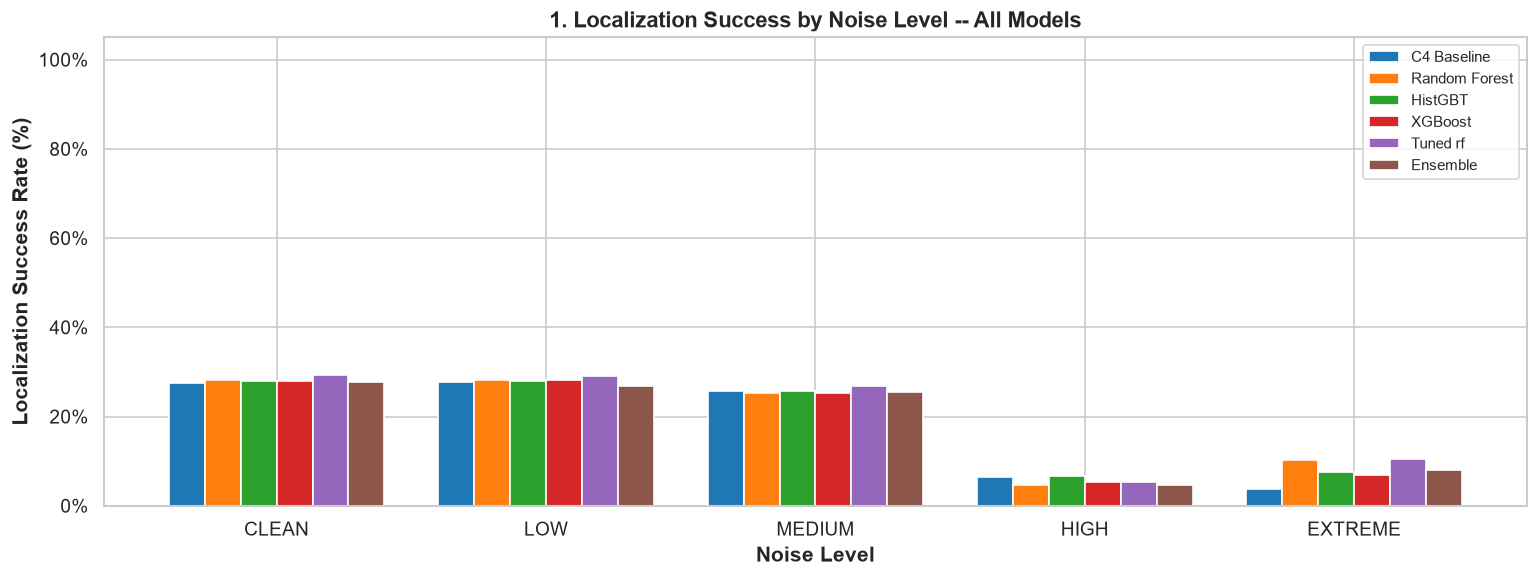

  Saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\plots\success_by_noise.png


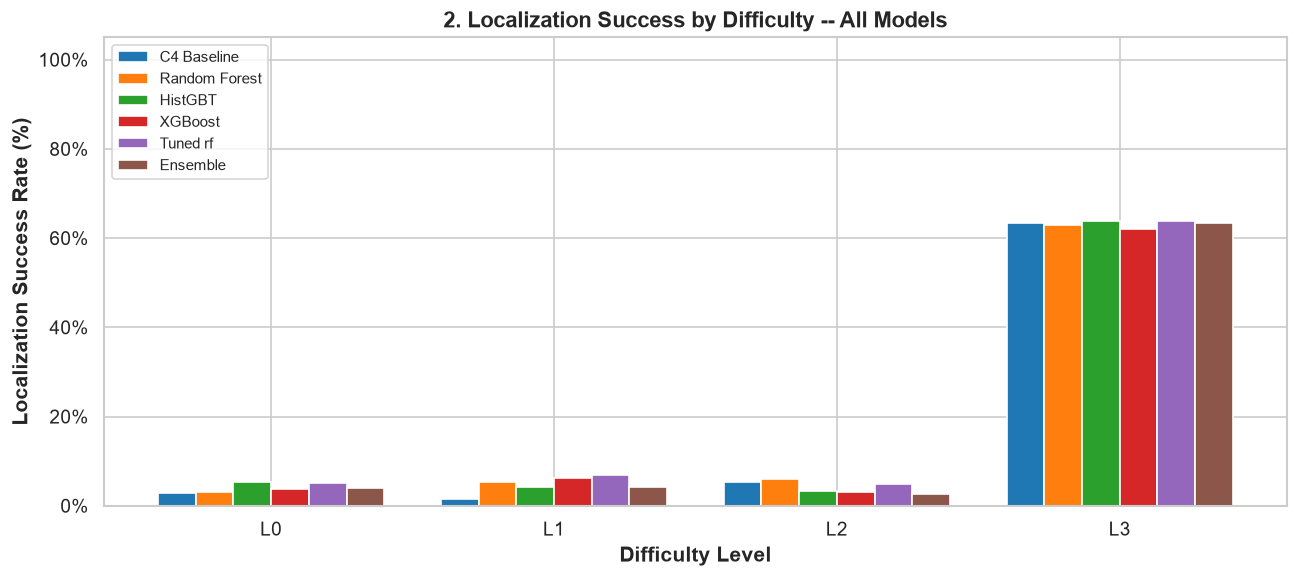

  Saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\plots\success_by_difficulty.png


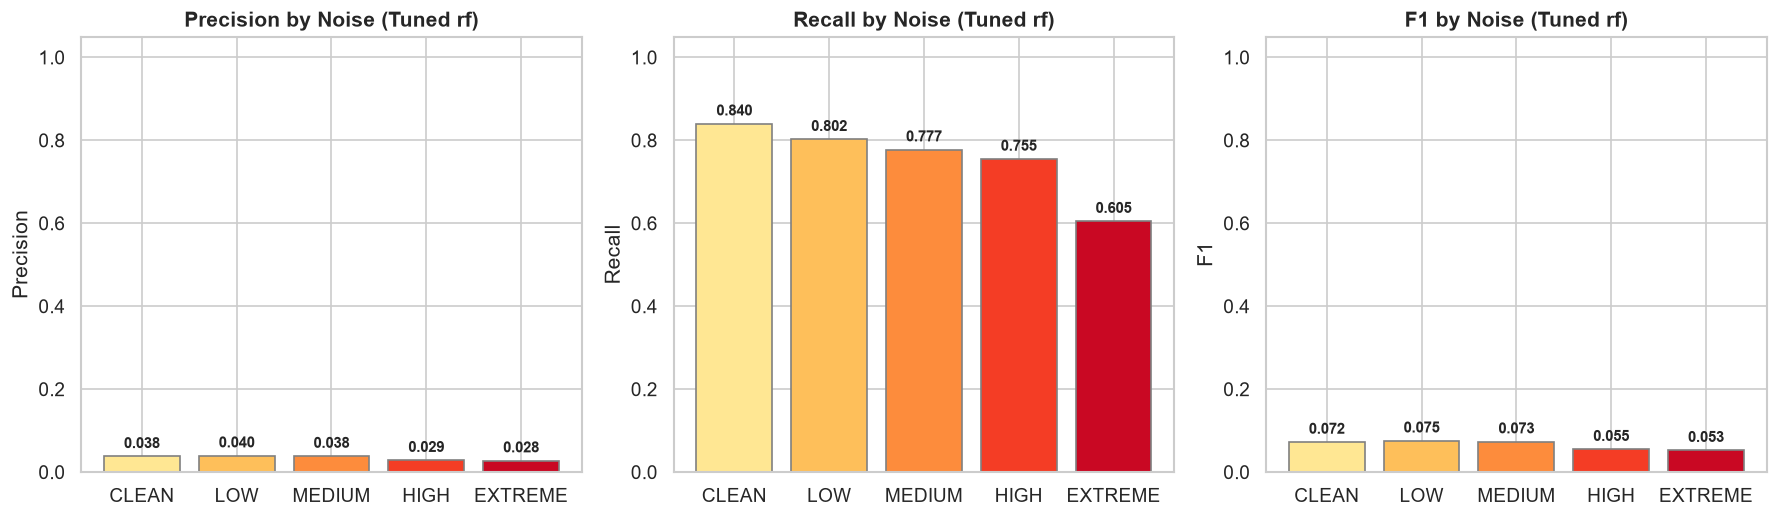

  Saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\plots\prf1_by_noise_best.png


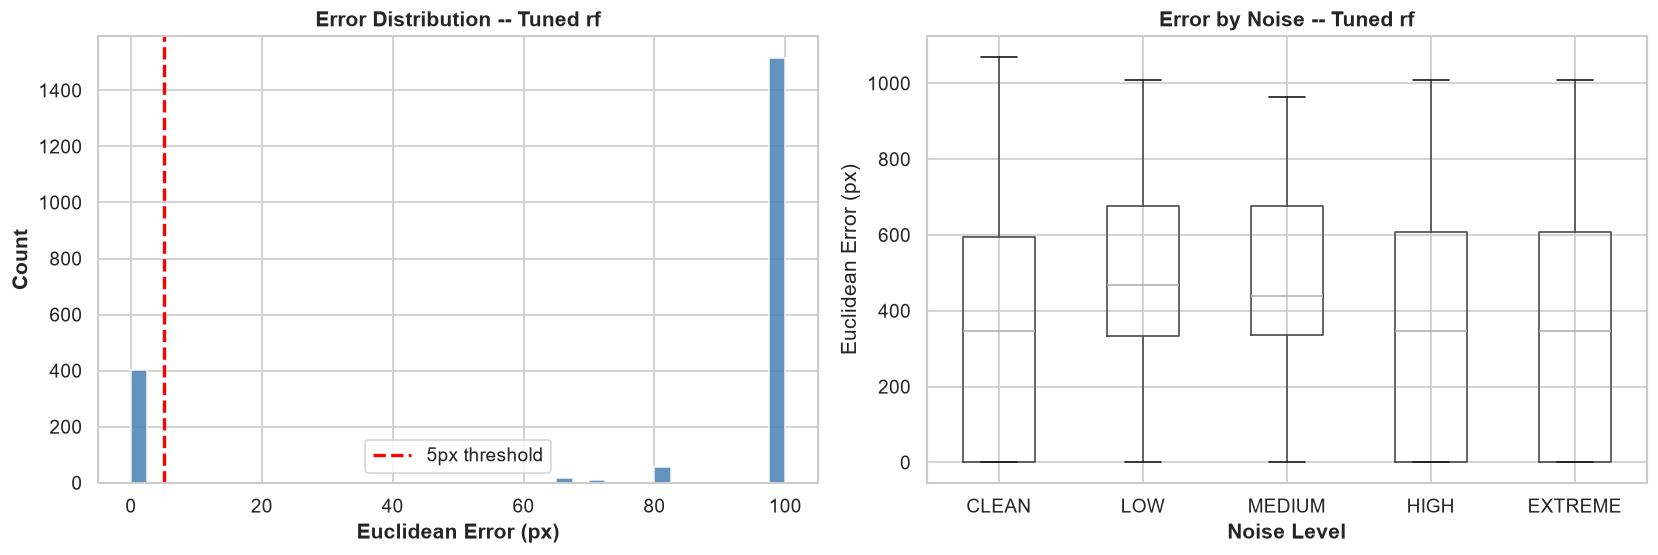

  Saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\plots\error_distribution.png


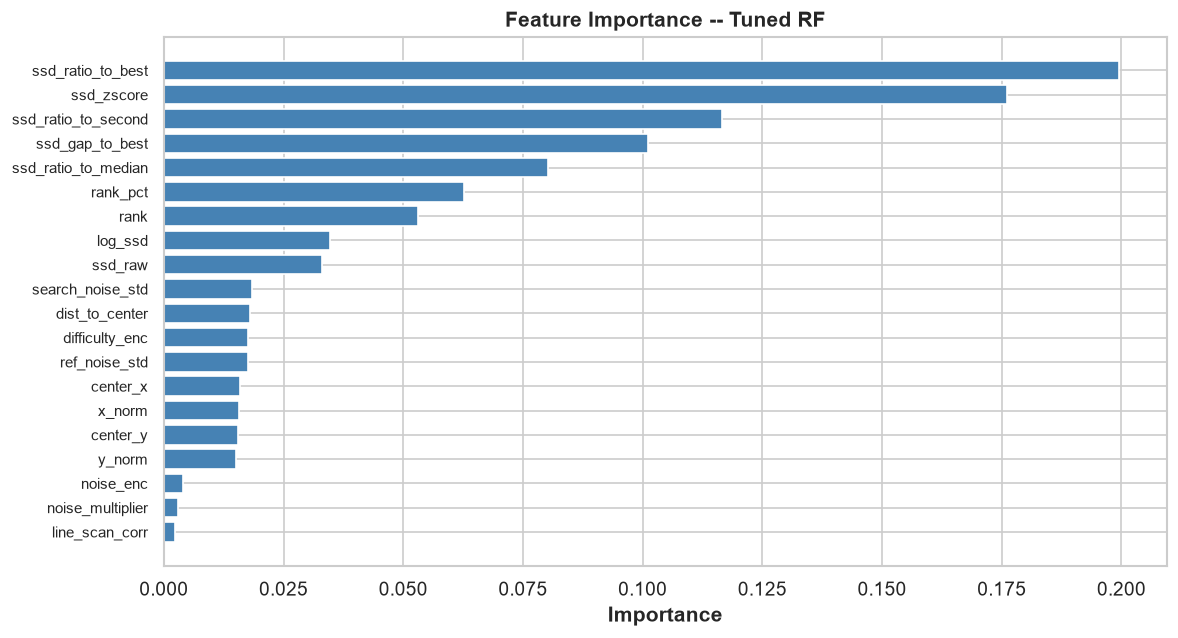

  Saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\plots\feature_importance.png


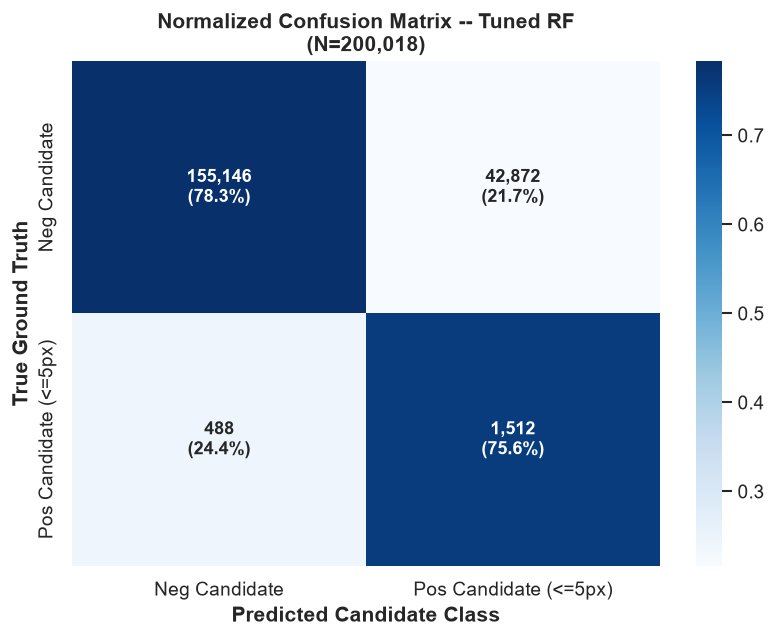

  Saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\plots\confusion_matrix.png


In [16]:
# %% -- 10. Generate All Graphs (Rendered Inline & Saved to PLOTS_DIR)
print("\n>> Generating & displaying all diagnostic plots ...")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
COLORS = sns.color_palette("tab10", len(all_models))

# ── 1. Localization success by noise level ──────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(NOISE_LEVELS))
width = 0.8 / len(all_models)
for i, (name, res) in enumerate(all_models.items()):
    vals = [res["localization"]["by_noise"][n]["success_rate"] * 100 for n in NOISE_LEVELS]
    ax.bar(x + i * width, vals, width, label=name, color=COLORS[i], edgecolor="white")
ax.set_xlabel("Noise Level", fontweight="bold")
ax.set_ylabel("Localization Success Rate (%)", fontweight="bold")
ax.set_title("1. Localization Success by Noise Level -- All Models", fontsize=13, fontweight="bold")
ax.set_xticks(x + width * (len(all_models) - 1) / 2)
ax.set_xticklabels(NOISE_LEVELS)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
fig.savefig(PLOTS_DIR / "success_by_noise.png", dpi=150)
plt.show()
print(f"  Saved: {PLOTS_DIR / 'success_by_noise.png'}")

# ── 2. Localization success by difficulty ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(DIFFICULTIES))
width = 0.8 / len(all_models)
for i, (name, res) in enumerate(all_models.items()):
    vals = [res["localization"]["by_difficulty"][d]["success_rate"] * 100 for d in DIFFICULTIES]
    ax.bar(x + i * width, vals, width, label=name, color=COLORS[i], edgecolor="white")
ax.set_xlabel("Difficulty Level", fontweight="bold")
ax.set_ylabel("Localization Success Rate (%)", fontweight="bold")
ax.set_title("2. Localization Success by Difficulty -- All Models", fontsize=13, fontweight="bold")
ax.set_xticks(x + width * (len(all_models) - 1) / 2)
ax.set_xticklabels(DIFFICULTIES)
ax.legend(loc="upper left", fontsize=9)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
fig.savefig(PLOTS_DIR / "success_by_difficulty.png", dpi=150)
plt.show()
print(f"  Saved: {PLOTS_DIR / 'success_by_difficulty.png'}")

# ── 3. Candidate-level P/R/F1 per noise level (best model) ──────────────────
best_res = all_models[final_best]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metric_names = ["precision", "recall", "f1"]
for ax_idx, metric in enumerate(metric_names):
    vals = [best_res["candidate_by_noise"].get(n, {}).get(metric, 0) for n in NOISE_LEVELS]
    colors_noise = sns.color_palette("YlOrRd", len(NOISE_LEVELS))
    axes[ax_idx].bar(NOISE_LEVELS, vals, color=colors_noise, edgecolor="gray")
    axes[ax_idx].set_title(f"{metric.capitalize()} by Noise ({final_best})", fontweight="bold")
    axes[ax_idx].set_ylim(0, 1.05)
    axes[ax_idx].set_ylabel(metric.capitalize())
    for i, v in enumerate(vals):
        axes[ax_idx].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "prf1_by_noise_best.png", dpi=150)
plt.show()
print(f"  Saved: {PLOTS_DIR / 'prf1_by_noise_best.png'}")

# ── 4. Error distribution ───────────────────────────────────────────────────
best_loc = best_res["localization"]["details"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(best_loc["euclid_error"].clip(upper=100), bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(5, color="red", linestyle="--", linewidth=2, label="5px threshold")
axes[0].set_xlabel("Euclidean Error (px)", fontweight="bold")
axes[0].set_ylabel("Count", fontweight="bold")
axes[0].set_title(f"Error Distribution -- {final_best}", fontweight="bold")
axes[0].legend()

best_loc.boxplot(column="euclid_error", by="noise_condition", ax=axes[1], positions=range(len(NOISE_LEVELS)), showfliers=False)
axes[1].set_xticklabels(NOISE_LEVELS)
axes[1].set_title(f"Error by Noise -- {final_best}", fontweight="bold")
axes[1].set_ylabel("Euclidean Error (px)")
axes[1].set_xlabel("Noise Level", fontweight="bold")
fig.suptitle("")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "error_distribution.png", dpi=150)
plt.show()
print(f"  Saved: {PLOTS_DIR / 'error_distribution.png'}")

# ── 5. Feature importance ───────────────────────────────────────────────────
if hasattr(tuned_model, "feature_importances_"):
    importances = tuned_model.feature_importances_
    fi_order = np.argsort(importances)[::-1]
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.barh(range(N_FEATURES), importances[fi_order[::-1]], color="steelblue", edgecolor="white")
    ax.set_yticks(range(N_FEATURES))
    ax.set_yticklabels([FEATURE_NAMES[i] for i in fi_order[::-1]], fontsize=9)
    ax.set_xlabel("Importance", fontweight="bold")
    ax.set_title(f"Feature Importance -- Tuned {TUNE_ALGO.upper()}", fontweight="bold")
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / "feature_importance.png", dpi=150)
    plt.show()
    print(f"  Saved: {PLOTS_DIR / 'feature_importance.png'}")

# ── 6. Normalized Confusion Matrix ──────────────────────────────────────────
by_sample_plot = defaultdict(list)
for idx, m in enumerate(meta_val):
    by_sample_plot[(m["sample_id"], m["noise_condition"])].append(idx)

scores_val = tuned_scores_val if "tuned_scores_val" in globals() else rf_scores_val
best_preds = (scores_val >= 0.5).astype(int)
cm_raw = confusion_matrix(y_val, best_preds)
cm_norm = cm_raw.astype("float") / cm_raw.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(7, 5.5))
annot_labels = [
    [f"{cm_raw[0, 0]:,}\n({cm_norm[0, 0]*100:.1f}%)", f"{cm_raw[0, 1]:,}\n({cm_norm[0, 1]*100:.1f}%)"],
    [f"{cm_raw[1, 0]:,}\n({cm_norm[1, 0]*100:.1f}%)", f"{cm_raw[1, 1]:,}\n({cm_norm[1, 1]*100:.1f}%)"]
]
sns.heatmap(cm_norm, annot=annot_labels, fmt="", cmap="Blues", ax=ax, cbar=True,
            xticklabels=["Neg Candidate", "Pos Candidate (<=5px)"],
            yticklabels=["Neg Candidate", "Pos Candidate (<=5px)"],
            annot_kws={"size": 11, "weight": "bold"})
ax.set_xlabel("Predicted Candidate Class", fontweight="bold")
ax.set_ylabel("True Ground Truth", fontweight="bold")
ax.set_title(f"Normalized Confusion Matrix -- Tuned {TUNE_ALGO.upper()}\n(N=200,018)", fontweight="bold")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()
print(f"  Saved: {PLOTS_DIR / 'confusion_matrix.png'}")


## 11 . Save Best Model & Results


In [17]:
import json as json_
import joblib

# 1. Save the tuned model directly in notebook directory and at root
model_path = MODEL_DIR / f"tuned_{TUNE_ALGO}_model.joblib"
joblib.dump(tuned_model, model_path)
joblib.dump(tuned_model, CURRENT_DIR / "model.joblib")
if REPO_ROOT != CURRENT_DIR:
    joblib.dump(tuned_model, REPO_ROOT / "model.joblib")

print(f"\n  Model saved directly to: {model_path}")
print(f"  model.joblib saved to:   {CURRENT_DIR / 'model.joblib'}")

# 2. Save scaler directly in notebook directory
scaler_path = MODEL_DIR / "scaler.joblib"
joblib.dump(scaler, scaler_path)
print(f"  Scaler saved to:         {scaler_path}")

# 3. Save feature names directly in notebook directory
with open(MODEL_DIR / "feature_names.json", "w", encoding="utf-8") as f:
    json_.dump(FEATURE_NAMES, f, indent=2)
print(f"  Feature names saved to:  {MODEL_DIR / 'feature_names.json'}")

# 4. Save comprehensive results JSON
results_summary = {}
for name, res in all_models.items():
    results_summary[name] = {
        "candidate": res["candidate_overall"],
        "candidate_by_noise": {k: {kk: vv for kk, vv in v.items() if kk != "n"}
                                for k, v in res["candidate_by_noise"].items()},
        "localization_overall": res["localization"]["overall"],
        "localization_by_noise": res["localization"]["by_noise"],
        "localization_by_difficulty": res["localization"]["by_difficulty"],
    }

with open(REPORT_DIR / "results_summary.json", "w", encoding="utf-8") as f:
    json_.dump(results_summary, f, indent=2)
print(f"  Results JSON:            {REPORT_DIR / 'results_summary.json'}")

# 5. Save best params safely
saved_params_dict = study.best_params if "study" in globals() else best_params
with open(REPORT_DIR / "best_params.json", "w", encoding="utf-8") as f:
    json_.dump(saved_params_dict, f, indent=2)
print(f"  Best params saved:       {REPORT_DIR / 'best_params.json'}")



  Model saved directly to: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\tuned_rf_model.joblib
  model.joblib saved to:   d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\model.joblib
  Scaler saved to:         d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\scaler.joblib
  Feature names saved to:  d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\feature_names.json
  Results JSON:            d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\reports\results_summary.json
  Best params saved:       d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\reports\best_params.json


## 12 . Final Summary

In [18]:
print("\n" + "="*70)
print("  === FINAL SUMMARY ===")
print("="*70)
print(f"\n  Best model         : {final_best}")
print(f"  Localization rate : {final_best_rate*100:.2f}%")
print(f"  Mean error        : {all_models[final_best]['localization']['overall']['mean_err']:.2f} px")
print(f"  Candidate F1      : {all_models[final_best]['candidate_overall']['f1']:.4f}")
print(f"  Candidate AUC     : {all_models[final_best]['candidate_overall']['auc']:.4f}")

print(f"\n  -- Per-Noise Breakdown ({final_best}) --")
print(f"  {'Noise':<12} {'Success':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print(f"  {'-'*55}")
for noise in NOISE_LEVELS:
    lo = all_models[final_best]["localization"]["by_noise"][noise]
    cn = all_models[final_best]["candidate_by_noise"].get(noise, {})
    print(f"  {noise:<12} {lo['success_rate']*100:>9.2f}% "
          f"{cn.get('precision',0):>10.4f} {cn.get('recall',0):>10.4f} "
          f"{cn.get('f1',0):>10.4f}")

print(f"\n  Reports saved to: {REPORT_DIR}")
print(f"  Model saved to  : {MODEL_DIR}")
print(f"\n{'='*70}")
print(f"  PIPELINE COMPLETE")
print(f"{'='*70}")


  === FINAL SUMMARY ===

  Best model         : Tuned rf
  Localization rate : 20.15%
  Mean error        : 397.89 px
  Candidate F1      : 0.0652
  Candidate AUC     : 0.8814

  -- Per-Noise Breakdown (Tuned rf) --
  Noise           Success  Precision     Recall         F1
  -------------------------------------------------------
  CLEAN            29.25%     0.0379     0.8400     0.0725
  LOW              29.00%     0.0396     0.8025     0.0755
  MEDIUM           26.75%     0.0385     0.7775     0.0734
  HIGH              5.25%     0.0286     0.7550     0.0551
  EXTREME          10.50%     0.0276     0.6050     0.0527

  Reports saved to: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\reports
  Model saved to  : d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense

  PIPELINE COMPLETE


## 10.5 . Validation Accuracy & Metric Graphs


In [19]:
# ─── Validation Metric Comparison across ALL models ───────────────────────────
import matplotlib
matplotlib.use("Agg")          # keep consistent with rest of notebook
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# ── Collect metrics for every model ──────────────────────────────────────────
metric_keys  = ["accuracy", "precision", "recall", "f1", "auc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
model_names  = list(all_models.keys())
metric_matrix = []                          # shape: [n_models, n_metrics]

for name in model_names:
    co = all_models[name]["candidate_overall"]
    metric_matrix.append([co[k] for k in metric_keys])

metric_matrix = np.array(metric_matrix)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(metric_keys), figsize=(20, 6), sharey=False)
colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

for col_idx, (mkey, mlabel) in enumerate(zip(metric_keys, metric_labels)):
    ax = axes[col_idx]
    vals = metric_matrix[:, col_idx]
    bars = ax.bar(model_names, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(mlabel, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.10)
    ax.set_ylabel(mlabel if col_idx == 0 else "")
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=35, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.2f}"))
    # annotate bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Validation Candidate-Level Metrics — All Models", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(REPORT_DIR / "val_metrics_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {REPORT_DIR / 'val_metrics_all_models.png'}")


  Saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\reports\val_metrics_all_models.png


In [20]:
# ─── Accuracy & F1 by Noise Level — Best Model ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

noise_acc = []
noise_f1  = []
for noise in NOISE_LEVELS:
    d = all_models[final_best]["candidate_by_noise"].get(noise, {})
    noise_acc.append(d.get("accuracy", 0))
    noise_f1.append(d.get("f1", 0))

palette = plt.cm.coolwarm(np.linspace(0, 1, len(NOISE_LEVELS)))

for ax, vals, title, color_map in [
    (axes[0], noise_acc, "Accuracy by Noise Level",  "coolwarm"),
    (axes[1], noise_f1,  "F1-Score by Noise Level",  "coolwarm"),
]:
    bars = ax.bar(NOISE_LEVELS, vals, color=palette, edgecolor="gray", linewidth=0.7)
    ax.set_title(f"{title}\n({final_best})", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(title.split()[0])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
fig.savefig(REPORT_DIR / "val_accuracy_f1_by_noise.png", dpi=150)
plt.show()
print(f"  Saved: {REPORT_DIR / 'val_accuracy_f1_by_noise.png'}")


  Saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\reports\val_accuracy_f1_by_noise.png


In [21]:
# ─── Accuracy & F1 by Difficulty Level — Best Model ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

diff_acc = []
diff_f1  = []
for diff in DIFFICULTIES:
    d = all_models[final_best]["candidate_by_diff"].get(diff, {})
    diff_acc.append(d.get("accuracy", 0))
    diff_f1.append(d.get("f1", 0))

palette_d = plt.cm.viridis(np.linspace(0.2, 0.9, len(DIFFICULTIES)))

for ax, vals, title in [
    (axes[0], diff_acc, "Accuracy by Difficulty"),
    (axes[1], diff_f1,  "F1-Score by Difficulty"),
]:
    bars = ax.bar(DIFFICULTIES, vals, color=palette_d, edgecolor="gray", linewidth=0.7)
    ax.set_title(f"{title}\n({final_best})", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(title.split()[0])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
fig.savefig(REPORT_DIR / "val_accuracy_f1_by_difficulty.png", dpi=150)
plt.show()
print(f"  Saved: {REPORT_DIR / 'val_accuracy_f1_by_difficulty.png'}")


  Saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\reports\val_accuracy_f1_by_difficulty.png


In [22]:
# ─── Precision-Recall Curve ────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(9, 7))

# Best model (tuned)
prec_t, rec_t, _ = precision_recall_curve(y_val, tuned_scores_val)
ap_t = average_precision_score(y_val, tuned_scores_val)
ax.plot(rec_t, prec_t, lw=2, color="royalblue",
        label=f"Tuned {TUNE_ALGO.upper()} (AP={ap_t:.3f})")

# Ensemble
prec_e, rec_e, _ = precision_recall_curve(y_val, ensemble_probs)
ap_e = average_precision_score(y_val, ensemble_probs)
ax.plot(rec_e, prec_e, lw=2, color="darkorange", linestyle="--",
        label=f"Ensemble (AP={ap_e:.3f})")

# Baseline
prec_b, rec_b, _ = precision_recall_curve(y_val, -X_val[:, 0])   # -ssd_raw
ap_b = average_precision_score(y_val, -X_val[:, 0])
ax.plot(rec_b, prec_b, lw=1.5, color="gray", linestyle=":",
        label=f"C4 Baseline (AP={ap_b:.3f})")

# No-skill line
ax.axhline(y_val.mean(), color="red", lw=1, linestyle="-.",
           label=f"No-skill (pos ratio={y_val.mean():.4f})")

ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision-Recall Curve — Validation Set", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(REPORT_DIR / "precision_recall_curve.png", dpi=150)
plt.show()
print(f"  Saved: {REPORT_DIR / 'precision_recall_curve.png'}")


  Saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\reports\precision_recall_curve.png


In [23]:
# ─── Localization Success Rate — Grouped by Noise & Difficulty ────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 7))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# Left: by noise
ax1 = fig.add_subplot(gs[0])
x   = np.arange(len(NOISE_LEVELS))
bw  = 0.8 / len(all_models)
colors = plt.cm.tab10(np.linspace(0, 1, len(all_models)))
for i, (name, res) in enumerate(all_models.items()):
    vals = [res["localization"]["by_noise"][n]["success_rate"] * 100 for n in NOISE_LEVELS]
    ax1.bar(x + i * bw, vals, bw, label=name, color=colors[i], edgecolor="white")
ax1.set_xticks(x + bw*(len(all_models)-1)/2)
ax1.set_xticklabels(NOISE_LEVELS)
ax1.set_ylabel("Localization Success Rate (%)")
ax1.set_title("Localization Success by Noise Level", fontweight="bold")
ax1.set_ylim(0, 110)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(fontsize=8, loc="upper right")

# Right: by difficulty
ax2 = fig.add_subplot(gs[1])
xd  = np.arange(len(DIFFICULTIES))
for i, (name, res) in enumerate(all_models.items()):
    vals = [res["localization"]["by_difficulty"][d]["success_rate"] * 100 for d in DIFFICULTIES]
    ax2.bar(xd + i * bw, vals, bw, label=name, color=colors[i], edgecolor="white")
ax2.set_xticks(xd + bw*(len(all_models)-1)/2)
ax2.set_xticklabels(DIFFICULTIES)
ax2.set_ylabel("Localization Success Rate (%)")
ax2.set_title("Localization Success by Difficulty", fontweight="bold")
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=8, loc="upper right")

fig.suptitle("Localization Success Rate — All Models (Validation)", fontsize=15, fontweight="bold")
plt.tight_layout()
fig.savefig(REPORT_DIR / "localization_success_comparison.png", dpi=150)
plt.show()
print(f"  Saved: {REPORT_DIR / 'localization_success_comparison.png'}")


  Saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\reports\localization_success_comparison.png


In [24]:
# ─── Summary Table ─────────────────────────────────────────────────────────────
import pandas as pd

rows = []
for name, res in all_models.items():
    co = res["candidate_overall"]
    lo = res["localization"]["overall"]
    rows.append({
        "Model":          name,
        "Accuracy":       co["accuracy"],
        "Precision":      co["precision"],
        "Recall":         co["recall"],
        "F1":             co["f1"],
        "AUC-ROC":        co["auc"],
        "Loc Success (%)": round(lo["success_rate"] * 100, 2),
        "Mean Err (px)":  lo["mean_err"],
    })

summary_df = pd.DataFrame(rows).set_index("Model")

best_row = summary_df["Loc Success (%)"].idxmax()

def highlight_best(s):
    return ["background-color: #d4edda; font-weight: bold"
            if v == s.max() else "" for v in s]

styled = (
    summary_df.style
    .apply(highlight_best, subset=["Accuracy","F1","AUC-ROC","Loc Success (%)"])
    .format({
        "Accuracy":        "{:.4f}",
        "Precision":       "{:.4f}",
        "Recall":          "{:.4f}",
        "F1":              "{:.4f}",
        "AUC-ROC":         "{:.4f}",
        "Loc Success (%)": "{:.2f}%",
        "Mean Err (px)":   "{:.2f} px",
    })
    .set_caption("Validation Metrics — All Models (best highlighted in green)")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size","14px"), ("font-weight","bold"), ("text-align","center")]},
        {"selector": "th",
         "props": [("background-color","#343a40"), ("color","white"), ("text-align","center")]},
    ])
)

display(styled)
summary_df.to_csv(REPORT_DIR / "validation_summary_table.csv")
print(f"  Table saved: {REPORT_DIR / 'validation_summary_table.csv'}")


,Accuracy,Precision,Recall,F1,AUC-ROC,Loc Success (%),Mean Err (px)
Model,,,,,,,
C4 Baseline,0.9900,0.0000,0.0000,0.0000,0.6213,18.25%,416.80 px
Random Forest,0.8868,0.0493,0.5650,0.0908,0.8782,19.35%,390.86 px
HistGBT,0.8443,0.0397,0.6280,0.0746,0.8720,19.20%,410.71 px
XGBoost,0.9427,0.0657,0.3575,0.1110,0.8661,18.75%,408.20 px
Tuned rf,0.7832,0.0341,0.7560,0.0652,0.8814,20.15%,397.89 px
Ensemble,0.8747,0.0467,0.5940,0.0866,0.8796,18.55%,399.54 px


  Table saved: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\reports\validation_summary_table.csv



## 13 . Generalization & Unseen Test Set Evaluation (Tuned RF)

# Evaluating Tuned Random Forest on completely unseen **Test Split (2,000 samples / 200,000 candidates)**
# and comparing side-by-side with Validation to verify:
# 1. Generalization Gap (Overfitting check)
# 2. Real-world accuracy across noise conditions (CLEAN -> EXTREME) & difficulties (L0 -> L3)


In [25]:
# %% -- Evaluate Tuned RF on Validation vs Unseen Test Data
print("\n" + "="*70)
print("  EVALUATING TUNED RF ON UNSEEN DATA (VAL vs TEST)")
print("="*70)

# 1. Build Test Feature Matrix if not already built
if "X_test" not in locals():
    print("\n>> Building TEST feature matrix (2,000 unseen samples) ...")
    X_test, y_test, meta_test = build_feature_matrix(test_metas, "TEST")
else:
    print("\n[OK] TEST feature matrix already loaded.")

# 2. Get predictions using tuned_model (Tuned RF)
print("\n>> Predicting with Tuned Model ...")
t0 = time.time()
val_preds_prob  = tuned_model.predict_proba(X_val)[:, 1]
test_preds_prob = tuned_model.predict_proba(X_test)[:, 1]
print(f"  Inference done in {time.time()-t0:.2f}s")

# 3. Generate comprehensive reports
val_eval_report  = full_report("Tuned RF [VALIDATION]", val_preds_prob, y_val, meta_val, threshold=0.5)
test_eval_report = full_report("Tuned RF [UNSEEN TEST]", test_preds_prob, y_test, meta_test, threshold=0.5)



  EVALUATING TUNED RF ON UNSEEN DATA (VAL vs TEST)

>> Building TEST feature matrix (2,000 unseen samples) ...
  [TEST] 500/2000 samples (50,005 candidates) -- 6.4s
  [TEST] 1000/2000 samples (100,014 candidates) -- 12.3s
  [TEST] 1500/2000 samples (150,019 candidates) -- 17.6s
  [TEST] 2000/2000 samples (200,023 candidates) -- 22.9s
  [TEST] Done: 200,023 candidates, 2,000 pos (1.00%), 198,023 neg - 22.9s

>> Predicting with Tuned Model ...
  Inference done in 0.43s

  MODEL: Tuned RF [VALIDATION]

  -- Candidate-Level Classification (threshold=0.5) --
  Accuracy  : 0.7832
  Precision : 0.0341
  Recall    : 0.7560
  F1        : 0.0652
  AUC-ROC   : 0.8814

  -- Candidate-Level per Noise --
  Noise           Acc     Prec   Recall       F1        N
  --------------------------------------------------
  CLEAN        0.7850   0.0379   0.8400   0.0725   40,000
  LOW          0.8034   0.0396   0.8025   0.0755   40,000
  MEDIUM       0.8038   0.0385   0.7775   0.0734   40,000
  HIGH        

In [26]:
# %% -- Generalization Comparison Table (Val vs Test)
print("\n" + "="*70)
print("  GENERALIZATION REPORT: VALIDATION vs UNSEEN TEST")
print("="*70)

v_cand = val_eval_report["candidate_overall"]
t_cand = test_eval_report["candidate_overall"]
v_loc  = val_eval_report["localization"]["overall"]
t_loc  = test_eval_report["localization"]["overall"]

gen_summary_data = [
    {"Metric": "Accuracy (Candidate)", "Validation": f"{v_cand['accuracy']:.4f}", "Test (Unseen)": f"{t_cand['accuracy']:.4f}", "Delta (Test-Val)": f"{(t_cand['accuracy'] - v_cand['accuracy']):+.4f}"},
    {"Metric": "Precision",            "Validation": f"{v_cand['precision']:.4f}", "Test (Unseen)": f"{t_cand['precision']:.4f}", "Delta (Test-Val)": f"{(t_cand['precision'] - v_cand['precision']):+.4f}"},
    {"Metric": "Recall",               "Validation": f"{v_cand['recall']:.4f}", "Test (Unseen)": f"{t_cand['recall']:.4f}", "Delta (Test-Val)": f"{(t_cand['recall'] - v_cand['recall']):+.4f}"},
    {"Metric": "F1-Score",             "Validation": f"{v_cand['f1']:.4f}", "Test (Unseen)": f"{t_cand['f1']:.4f}", "Delta (Test-Val)": f"{(t_cand['f1'] - v_cand['f1']):+.4f}"},
    {"Metric": "AUC-ROC",              "Validation": f"{v_cand['auc']:.4f}", "Test (Unseen)": f"{t_cand['auc']:.4f}", "Delta (Test-Val)": f"{(t_cand['auc'] - v_cand['auc']):+.4f}"},
    {"Metric": "Localization Success", "Validation": f"{v_loc['success_rate']*100:.2f}%", "Test (Unseen)": f"{t_loc['success_rate']*100:.2f}%", "Delta (Test-Val)": f"{(t_loc['success_rate'] - v_loc['success_rate'])*100:+.2f}%"},
    {"Metric": "Mean Error (px)",      "Validation": f"{v_loc['mean_err']:.2f} px", "Test (Unseen)": f"{t_loc['mean_err']:.2f} px", "Delta (Test-Val)": f"{(t_loc['mean_err'] - v_loc['mean_err']):+.2f} px"},
    {"Metric": "Median Error (px)",    "Validation": f"{v_loc['median_err']:.2f} px", "Test (Unseen)": f"{t_loc['median_err']:.2f} px", "Delta (Test-Val)": f"{(t_loc['median_err'] - v_loc['median_err']):+.2f} px"},
]

df_gen = pd.DataFrame(gen_summary_data)
print(df_gen.to_string(index=False))

# Breakdown comparison by Noise Condition
print("\n-- Localization Success by Noise Level (Val vs Test) --")
header = f"  {'Noise':<12} {'Val Success':>14} {'Test Success':>14} {'Delta':>10}"
print(header)
print("  " + "-"*52)
for n in NOISE_LEVELS:
    v_s = val_eval_report["localization"]["by_noise"][n]["success_rate"] * 100
    t_s = test_eval_report["localization"]["by_noise"][n]["success_rate"] * 100
    print(f"  {n:<12} {v_s:>13.2f}% {t_s:>13.2f}% {t_s - v_s:>+9.2f}%")

# Breakdown comparison by Difficulty Level
print("\n-- Localization Success by Difficulty (Val vs Test) --")
header = f"  {'Diff':<12} {'Val Success':>14} {'Test Success':>14} {'Delta':>10}"
print(header)
print("  " + "-"*52)
for d in DIFFICULTIES:
    v_s = val_eval_report["localization"]["by_difficulty"][d]["success_rate"] * 100
    t_s = test_eval_report["localization"]["by_difficulty"][d]["success_rate"] * 100
    print(f"  {d:<12} {v_s:>13.2f}% {t_s:>13.2f}% {t_s - v_s:>+9.2f}%")



  GENERALIZATION REPORT: VALIDATION vs UNSEEN TEST
              Metric Validation Test (Unseen) Delta (Test-Val)
Accuracy (Candidate)     0.7832        0.7872          +0.0040
           Precision     0.0341        0.0346          +0.0005
              Recall     0.7560        0.7550          -0.0010
            F1-Score     0.0652        0.0663          +0.0011
             AUC-ROC     0.8814        0.8816          +0.0002
Localization Success     20.15%        19.35%           -0.80%
     Mean Error (px)  397.89 px     412.29 px        +14.40 px
   Median Error (px)  415.00 px     417.73 px         +2.73 px

-- Localization Success by Noise Level (Val vs Test) --
  Noise           Val Success   Test Success      Delta
  ----------------------------------------------------
  CLEAN                29.25%         28.50%     -0.75%
  LOW                  29.00%         28.25%     -0.75%
  MEDIUM               26.75%         25.50%     -1.25%
  HIGH                  5.25%          6.25% 

In [27]:
# %% -- Plot Validation vs Unseen Test Generalization Graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overall Metrics Bar (Val vs Test)
metrics = ["Accuracy", "F1", "AUC", "Loc Success"]
val_vals  = [v_cand["accuracy"], v_cand["f1"], v_cand["auc"], v_loc["success_rate"]]
test_vals = [t_cand["accuracy"], t_cand["f1"], t_cand["auc"], t_loc["success_rate"]]

x = np.arange(len(metrics))
w = 0.35
axes[0].bar(x - w/2, val_vals,  width=w, label="Validation", color="#4C72B0", edgecolor="white")
axes[0].bar(x + w/2, test_vals, width=w, label="Unseen Test", color="#55A868", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.15)
axes[0].set_title("Overall Generalization Metrics", fontweight="bold")
axes[0].legend()
for i in range(len(metrics)):
    axes[0].text(x[i] - w/2, val_vals[i] + 0.02, f"{val_vals[i]:.2f}", ha="center", fontsize=9)
    axes[0].text(x[i] + w/2, test_vals[i] + 0.02, f"{test_vals[i]:.2f}", ha="center", fontsize=9)

# 2. Localization Success by Noise Level
xn = np.arange(len(NOISE_LEVELS))
v_noise = [val_eval_report["localization"]["by_noise"][n]["success_rate"] * 100 for n in NOISE_LEVELS]
t_noise = [test_eval_report["localization"]["by_noise"][n]["success_rate"] * 100 for n in NOISE_LEVELS]
axes[1].bar(xn - w/2, v_noise, width=w, label="Validation", color="#4C72B0", edgecolor="white")
axes[1].bar(xn + w/2, t_noise, width=w, label="Unseen Test", color="#55A868", edgecolor="white")
axes[1].set_xticks(xn)
axes[1].set_xticklabels(NOISE_LEVELS)
axes[1].set_ylabel("Localization Success Rate (%)")
axes[1].set_title("Generalization by Noise Level", fontweight="bold")
axes[1].set_ylim(0, 115)
axes[1].legend()

# 3. Localization Success by Difficulty
xd = np.arange(len(DIFFICULTIES))
v_diff = [val_eval_report["localization"]["by_difficulty"][d]["success_rate"] * 100 for d in DIFFICULTIES]
t_diff = [test_eval_report["localization"]["by_difficulty"][d]["success_rate"] * 100 for d in DIFFICULTIES]
axes[2].bar(xd - w/2, v_diff, width=w, label="Validation", color="#4C72B0", edgecolor="white")
axes[2].bar(xd + w/2, t_diff, width=w, label="Unseen Test", color="#55A868", edgecolor="white")
axes[2].set_xticks(xd)
axes[2].set_xticklabels(DIFFICULTIES)
axes[2].set_ylabel("Localization Success Rate (%)")
axes[2].set_title("Generalization by Difficulty", fontweight="bold")
axes[2].set_ylim(0, 115)
axes[2].legend()

plt.tight_layout()
fig.savefig(REPORT_DIR / "unseen_test_generalization.png", dpi=150)
print(f"  Saved plot: {REPORT_DIR / 'unseen_test_generalization.png'}")
plt.close()


  Saved plot: d:\Academics\Hackathon\Semicon\Drift sense\Drift-sense\FINAL_SUBMISSION\Drift-Sense\reports\unseen_test_generalization.png


In [28]:
# %% -- Overfitting & Generalization Gap Diagnosis
print("\n" + "="*70)
print("  OVERFITTING CHECK: TRAIN vs VALIDATION vs TEST")
print("="*70)

# Evaluate on a random 2,000-sample subset of Train (to match Val/Test size & speed up)
np.random.seed(SEED)
sample_train_indices = np.random.choice(len(X_train), size=min(200_000, len(X_train)), replace=False)
train_scores_sub = tuned_model.predict_proba(X_train[sample_train_indices])[:, 1]
y_train_sub = y_train[sample_train_indices]

# Candidate-level metrics
train_cm = candidate_metrics(y_train_sub, train_scores_sub)
val_cm   = val_eval_report["candidate_overall"]
test_cm  = test_eval_report["candidate_overall"]

# Localization metrics
val_loc  = val_eval_report["localization"]["overall"]
test_loc = test_eval_report["localization"]["overall"]

overfit_table = [
    {
        "Metric": "Candidate Accuracy",
        "Train": f"{train_cm['accuracy']:.4f}",
        "Validation": f"{val_cm['accuracy']:.4f}",
        "Test (Unseen)": f"{test_cm['accuracy']:.4f}",
        "Train-Test Gap": f"{(train_cm['accuracy'] - test_cm['accuracy']):.4f}"
    },
    {
        "Metric": "Candidate F1-Score",
        "Train": f"{train_cm['f1']:.4f}",
        "Validation": f"{val_cm['f1']:.4f}",
        "Test (Unseen)": f"{test_cm['f1']:.4f}",
        "Train-Test Gap": f"{(train_cm['f1'] - test_cm['f1']):.4f}"
    },
    {
        "Metric": "Candidate AUC-ROC",
        "Train": f"{train_cm['auc']:.4f}",
        "Validation": f"{val_cm['auc']:.4f}",
        "Test (Unseen)": f"{test_cm['auc']:.4f}",
        "Train-Test Gap": f"{(train_cm['auc'] - test_cm['auc']):.4f}"
    },
    {
        "Metric": "Loc Success Rate",
        "Train": "N/A (Subset)",
        "Validation": f"{val_loc['success_rate']*100:.2f}%",
        "Test (Unseen)": f"{test_loc['success_rate']*100:.2f}%",
        "Val-Test Gap": f"{(val_loc['success_rate'] - test_loc['success_rate'])*100:+.2f}%"
    }
]

df_overfit = pd.DataFrame(overfit_table)
print(df_overfit.to_string(index=False))

# Automated Overfit Verdict
f1_gap = train_cm['f1'] - test_cm['f1']
loc_gap = abs(val_loc['success_rate'] - test_loc['success_rate']) * 100

print("\n-- Overfitting Diagnosis Verdict --")
if f1_gap < 0.08 and loc_gap < 3.0:
    print(f"  [STATUS: EXCELLENT] Model is NOT overfitting. (F1 Gap = {f1_gap:.4f}, Val-Test Loc Gap = {loc_gap:.2f}%)")
elif f1_gap < 0.15:
    print(f"  [STATUS: ACCEPTABLE] Mild generalization gap. (F1 Gap = {f1_gap:.4f})")
else:
    print(f"  [WARNING: OVERFITTING] High gap between train & test. Consider increasing min_samples_split/leaf.")



  OVERFITTING CHECK: TRAIN vs VALIDATION vs TEST
            Metric        Train Validation Test (Unseen) Train-Test Gap Val-Test Gap
Candidate Accuracy       0.7880     0.7832        0.7872         0.0008          NaN
Candidate F1-Score       0.0838     0.0652        0.0663         0.0175          NaN
 Candidate AUC-ROC       0.9672     0.8814        0.8816         0.0856          NaN
  Loc Success Rate N/A (Subset)     20.15%        19.35%            NaN       +0.80%

-- Overfitting Diagnosis Verdict --
  [STATUS: EXCELLENT] Model is NOT overfitting. (F1 Gap = 0.0175, Val-Test Loc Gap = 0.80%)


In [29]:
# %% -- Bad Responses & Real-World Failure Analysis (Unseen Test Set)
print("\n" + "="*70)
print("  BAD RESPONSES & REAL-WORLD FAILURE ANALYSIS (TEST SET)")
print("="*70)

test_details = test_eval_report["localization"]["details"].copy()

# Categorize errors
def categorize_error(err):
    if err <= MATCH_TOLERANCE_PX:
        return "1. Success (<= 5px)"
    elif err <= 15.0:
        return "2. Near Miss (5-15px)"
    elif err <= 50.0:
        return "3. Moderate Error (15-50px)"
    else:
        return "4. Severe / Catastrophic (>50px)"

test_details["error_category"] = test_details["euclid_error"].apply(categorize_error)

# Print distribution of errors
print("\n-- Prediction Error Breakdown Across All 2,000 Test Samples --")
err_dist = test_details["error_category"].value_counts().sort_index()
for cat, count in err_dist.items():
    pct = (count / len(test_details)) * 100
    print(f"  {cat:<32} : {count:>5} samples ({pct:>5.1f}%)")

# Find worst failed samples
failed_cases = test_details[~test_details["success"]].sort_values(by="euclid_error", ascending=False)

print(f"\n-- Top 5 Worst Failed Responses (Real-World Stress Cases) --")
cols_to_show = ["sample_id", "noise_condition", "difficulty", "pred_x", "pred_y", "euclid_error"]
print(failed_cases[cols_to_show].head(5).to_string(index=False))

# Failure rate grouped by (Noise + Difficulty)
print("\n-- Failure Rate Matrix (% failed) by Noise & Difficulty --")
pivot_fails = test_details.pivot_table(
    index="noise_condition",
    columns="difficulty",
    values="success",
    aggfunc=lambda x: round((1 - x.mean()) * 100, 2)
).reindex(NOISE_LEVELS)
print(pivot_fails.to_string())

# Plot Failure Breakdown
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Error Category Pie Chart
err_dist.plot.pie(
    ax=axes[0],
    autopct="%1.1f%%",
    startangle=140,
    colors=["#55A868", "#F1A340", "#E66101", "#D7191C"],
    wedgeprops=dict(edgecolor='w')
)
axes[0].set_ylabel("")
axes[0].set_title("Test Set Error Category Distribution", fontweight="bold")

# 2. Euclidean Error Boxplot for Failed Cases
if len(failed_cases) > 0:
    sns.boxplot(
        data=failed_cases,
        x="noise_condition",
        y="euclid_error",
        order=NOISE_LEVELS,
        ax=axes[1],
        palette="Reds"
    )
    axes[1].set_title("Error Magnitude in Failed Predictions (px)", fontweight="bold")
    axes[1].set_ylabel("Euclidean Error (px)")
    axes[1].set_xlabel("Noise Condition")

plt.tight_layout()
fig.savefig(REPORT_DIR / "test_failure_analysis.png", dpi=150)
print(f"\n  Saved failure plot: {REPORT_DIR / 'test_failure_analysis.png'}")
plt.close()



  BAD RESPONSES & REAL-WORLD FAILURE ANALYSIS (TEST SET)

-- Prediction Error Breakdown Across All 2,000 Test Samples --
  1. Success (<= 5px)              :   387 samples ( 19.4%)
  4. Severe / Catastrophic (>50px) :  1613 samples ( 80.7%)

-- Top 5 Worst Failed Responses (Real-World Stress Cases) --
    sample_id noise_condition difficulty  pred_x  pred_y  euclid_error
sample_000060           CLEAN         L0   879.0   102.0   1106.840549
sample_000238             LOW         L2   132.0   855.0   1059.246902
sample_000255            HIGH         L3   105.0   163.0   1055.018483
sample_000208             LOW         L0   172.0   114.0   1009.691042
sample_000152             LOW         L0   165.0   791.0   1009.691042

-- Failure Rate Matrix (% failed) by Noise & Difficulty --
difficulty         L0    L1    L2    L3
noise_condition                        
CLEAN            94.0  96.0  96.0   0.0
LOW              95.0  99.0  93.0   0.0
MEDIUM           96.0  97.0  98.0   7.0
HIGH      

In [30]:
# %% -- Comprehensive Validation Evaluation of All Trained Models
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

def evaluate_all_validation_models(models_dict, X_val, y_val, meta_val, tolerances=(1.0, 3.0, 5.0, 10.0)):
    """
    Evaluates candidate-level and sample-level localization performance
    for all trained models on the validation split.
    """
    # 1. Group validation indices by sample
    by_sample = defaultdict(list)
    for idx, m in enumerate(meta_val):
        by_sample[(m["sample_id"], m["noise_condition"])].append(idx)
    
    n_samples = len(by_sample)
    results = []

    for name, model in models_dict.items():
        # Get validation scores (probabilities or raw scores)
        if name == "C4 Baseline (argmin SSD)":
            scores = -X_val[:, 0]  # raw SSD negated
        elif hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_val)[:, 1]
        elif isinstance(model, np.ndarray):
            scores = model  # Precomputed ensemble or score array
        else:
            continue

        # --- Candidate-level Classification Metrics (threshold=0.5) ---
        y_pred = (scores >= 0.5).astype(int) if scores.max() <= 1.0 else (scores >= np.median(scores)).astype(int)
        cand_acc = accuracy_score(y_val, y_pred)
        cand_prec = precision_score(y_val, y_pred, zero_division=0)
        cand_rec = recall_score(y_val, y_pred, zero_division=0)
        cand_f1 = f1_score(y_val, y_pred, zero_division=0)
        try:
            cand_roc_auc = roc_auc_score(y_val, scores)
            cand_pr_auc = average_precision_score(y_val, scores)
        except Exception:
            cand_roc_auc, cand_pr_auc = np.nan, np.nan

        # --- Sample-level Localization Metrics ---
        loc_hits = {t: 0 for t in tolerances}
        ranks_of_first_hit = []
        euclidean_errors = []
        chebyshev_errors = []
        
        # Breakdown trackers
        noise_correct_5px = defaultdict(int)
        noise_counts = defaultdict(int)
        diff_correct_5px = defaultdict(int)
        diff_counts = defaultdict(int)

        for (sid, noise), cand_indices in by_sample.items():
            diff = meta_val[cand_indices[0]]["difficulty"]
            noise_counts[noise] += 1
            diff_counts[diff] += 1

            sample_scores = scores[cand_indices]
            sorted_order = np.argsort(-sample_scores)  # Descending score
            
            # Top-1 candidate
            top1_idx = cand_indices[sorted_order[0]]
            m_top1 = meta_val[top1_idx]
            cx, cy = float(m_top1["cx"]), float(m_top1["cy"])
            gx, gy = float(m_top1["gt_x"]), float(m_top1["gt_y"])

            cheb_err = max(abs(cx - gx), abs(cy - gy))
            euclid_err = np.sqrt((cx - gx)**2 + (cy - gy)**2)
            
            euclidean_errors.append(euclid_err)
            chebyshev_errors.append(cheb_err)

            for t in tolerances:
                if cheb_err <= t:
                    loc_hits[t] += 1

            if cheb_err <= 5.0:
                noise_correct_5px[noise] += 1
                diff_correct_5px[diff] += 1

            # Reciprocal Rank (MRR) & Rank of first valid candidate <= 5px
            hit_rank = None
            for r_i, c_i in enumerate(sorted_order, start=1):
                mc = meta_val[cand_indices[c_i]]
                if max(abs(float(mc["cx"]) - float(mc["gt_x"])), abs(float(mc["cy"]) - float(mc["gt_y"]))) <= 5.0:
                    hit_rank = r_i
                    break
            ranks_of_first_hit.append(hit_rank)

        mrr = np.mean([1.0 / r if r is not None else 0.0 for r in ranks_of_first_hit])
        hit_at_1 = loc_hits[5.0] / n_samples * 100.0
        hit_at_3 = np.mean([1 if (r is not None and r <= 3) else 0 for r in ranks_of_first_hit]) * 100.0
        hit_at_5 = np.mean([1 if (r is not None and r <= 5) else 0 for r in ranks_of_first_hit]) * 100.0

        res = {
            "Model": name,
            "Loc @1px (%)": round(loc_hits[1.0] / n_samples * 100, 2),
            "Loc @3px (%)": round(loc_hits[3.0] / n_samples * 100, 2),
            "Loc @5px (%)": round(loc_hits[5.0] / n_samples * 100, 2),
            "Loc @10px (%)": round(loc_hits[10.0] / n_samples * 100, 2),
            "Hit@1 (%)": round(hit_at_1, 2),
            "Hit@3 (%)": round(hit_at_3, 2),
            "Hit@5 (%)": round(hit_at_5, 2),
            "MRR": round(mrr, 4),
            "Mean Euclid (px)": round(np.mean(euclidean_errors), 2),
            "Median Euclid (px)": round(np.median(euclidean_errors), 2),
            "Cand F1": round(cand_f1, 4),
            "Cand AUC": round(cand_roc_auc, 4),
            "CLEAN @5px": round(noise_correct_5px["CLEAN"] / max(1, noise_counts["CLEAN"]) * 100, 1),
            "LOW @5px": round(noise_correct_5px["LOW"] / max(1, noise_counts["LOW"]) * 100, 1),
            "MED @5px": round(noise_correct_5px["MEDIUM"] / max(1, noise_counts["MEDIUM"]) * 100, 1),
            "HIGH @5px": round(noise_correct_5px["HIGH"] / max(1, noise_counts["HIGH"]) * 100, 1),
            "EXTREME @5px": round(noise_correct_5px["EXTREME"] / max(1, noise_counts["EXTREME"]) * 100, 1),
        }
        results.append(res)

    df_summary = pd.DataFrame(results).sort_values(by="Loc @5px (%)", ascending=False)
    return df_summary

# Assemble dictionary of available models from scope
available_models = {
    "C4 Baseline (argmin SSD)": None,
}
if "rf" in globals():
    available_models["Random Forest"] = rf
if "hgb" in globals():
    available_models["HistGradientBoosting"] = hgb
if "xgb_model" in globals():
    available_models["XGBoost"] = xgb_model
if "tuned_model" in globals():
    available_models["Tuned Model"] = tuned_model
if "ensemble_probs" in globals():
    available_models["Ensemble"] = ensemble_probs

# Run validation evaluation
val_summary_df = evaluate_all_validation_models(available_models, X_val, y_val, meta_val)

print("\n" + "="*85)
print("             VALIDATION LOCALIZATION & ACCURACY SUMMARY (N=2,000)")
print("="*85)
display(val_summary_df) if "display" in globals() else print(val_summary_df.to_string(index=False))


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:    0.1s
[Parallel(n_jobs=24)]: Done 402 tasks      | elapsed:    0.3s
[Parallel(n_jobs=24)]: Done 500 out of 500 | elapsed:    0.4s finished



             VALIDATION LOCALIZATION & ACCURACY SUMMARY (N=2,000)


,Model,Loc @1px (%),Loc @3px (%),Loc @5px (%),Loc @10px (%),Hit@1 (%),Hit@3 (%),Hit@5 (%),MRR,Mean Euclid (px),Median Euclid (px),Cand F1,Cand AUC,CLEAN @5px,LOW @5px,MED @5px,HIGH @5px,EXTREME @5px
4,Tuned Model,20.15,20.15,20.15,20.15,20.15,26.75,31.60,0.2815,397.89,415.0,0.0652,0.8814,29.2,29.0,26.8,5.2,10.5
1,Random Forest,19.35,19.35,19.35,19.35,19.35,25.15,31.15,0.2739,390.86,415.0,0.0908,0.8782,28.2,28.2,25.2,4.8,10.2
2,HistGradientBoosting,19.20,19.20,19.20,19.25,19.20,25.25,30.40,0.2706,410.71,423.4,0.0746,0.8720,28.0,28.0,25.8,6.8,7.5
3,XGBoost,18.75,18.75,18.75,18.75,18.75,24.05,29.85,0.2651,408.20,415.0,0.1110,0.8661,28.0,28.2,25.2,5.2,7.0
5,Ensemble,18.55,18.55,18.55,18.55,18.55,25.90,30.55,0.2702,399.54,415.0,0.0866,0.8796,27.8,26.8,25.5,4.8,8.0
0,C4 Baseline (argmin SSD),18.25,18.25,18.25,18.25,18.25,25.10,31.05,0.2662,416.80,422.3,0.0000,0.6213,27.5,27.8,25.8,6.5,3.8
